In [2]:
from importlib import reload
# reload(simulation_functions)
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from scipy.optimize import minimize

In [3]:
from scripts import simulation_functions

# Basic Bayesian learning 


In [4]:
scenes, languages = simulation_functions.define_objects()

In [5]:
# (interpretation function, word order, scene, agent x action x patient)
# contains the word that the language uses for each scene
languages.shape

(5040, 6, 36, 3)

In [6]:
5040*6

30240

Run single experiment:

In [323]:
n_trials = 50
n_participants = 6
noise_vector_uniform = np.linspace(0.2, 0.5, n_participants)
noise_vector_ignore = np.linspace(0.2, 0.95, n_participants)

In [324]:
print(noise_vector_ignore)
print(noise_vector_uniform)

[0.2  0.35 0.5  0.65 0.8  0.95]
[0.2  0.26 0.32 0.38 0.44 0.5 ]


In [ ]:
bayesian_results_noisefree = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=0,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=6)

In [325]:
bayesian_results_ignore = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector_ignore,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=6)

In [326]:
bayesian_results_uniform = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector_uniform,
    return_p_scene=True,
    noise_type='uniform'
)

IntProgress(value=0, max=6)

In [340]:
def minimize_for_cascade(true_probs):
    def p_max_prod(params):
        p_max, s, T = params
        trials = np.arange(len(true_probs))
        probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
        return np.sum((probs - true_probs)**2)
    return p_max_prod

def minimize_for_logistic(true_probs):
    def logistic_func(beta):
        trials = np.arange(len(true_probs))
        intercept = np.log(0.25 / (1 - 0.25))
        logistic_curve = 1 / (1 + np.exp(-(intercept + trials*beta)))
        return np.sum((logistic_curve - true_probs)**2)
    return logistic_func


def plot_bayesian_results(bayesian_results_dict, noise_vectors, save=False, pmax_for_true=None, x_max=None, pathadd=''):
    """
    pmax_for_true: ceiling probability of correct for the Bayesian model/approximation thereof
    """
    correct_fig, correct_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(6, 3), sharex=True, sharey=True
    )

    probs_fig, probs_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(6, 3), sharex=True, sharey=True
    )

    for j, ((noisetype, bayesian_results), noise_vector) in enumerate(zip(bayesian_results_dict.items(), noise_vectors)):

        hist_p_scenes = bayesian_results['history_p_scenes']
        n_trials, n_participants, _ = hist_p_scenes.shape

        history_states = bayesian_results['history_states']
        true_interpretation_func, true_word_order = bayesian_results['indices_true_language'].T
        
        probs_true_langs = history_states[
            :,
            np.arange(n_participants),
            true_interpretation_func, 
            true_word_order
        ]

        # probability of selecting the correct scene
        # given distribution over languages
        p_correct_scene = (
            hist_p_scenes[bayesian_results['true_scenes'][:,:,None] 
            == bayesian_results['indices_scenes_trials']]
            .reshape(n_trials,-1)
        )

        axrow_correct = correct_axs[j]
        axrow_probs = probs_axs[j]

        for i, (ax_correct,ax_probs,x,y,noise) in enumerate(zip(
            axrow_correct, axrow_probs, p_correct_scene.T, probs_true_langs.T, noise_vector)):
            
            if pmax_for_true is not None:
                x = np.minimum(x, pmax_for_true)

            result = minimize(
                minimize_for_cascade(x), 
                x0=[0.8, 0.5, 10],
                bounds=[(0,1), (1,None), (0, len(x))]
            )

            def p_max_prod(params):
                p_max, s, T = params
                trials = np.arange(len(x))
                return np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
            
            def logistic_func(beta):
                trials = np.arange(len(x))
                intercept = np.log(0.25 / (1 - 0.25))
                return 1 / (1 + np.exp(-(intercept + trials*beta)))

            result_logistic = minimize(
                minimize_for_logistic(x), 
                x0=[0.8],
                # bounds=[]
            )

            ax_correct.plot(x, color='gray', label='true probability')
            ax_probs.plot(y, color='gray')

            # probabilities right choice with maximum likelihood parameters
            probs_choices = p_max_prod(result.x)
            ax_correct.plot(probs_choices, color='red', alpha=1.0, lw=0.5, ls='--', label='cascade model')
            probs_choices_logistic = logistic_func(result_logistic.x)
            ax_correct.plot(probs_choices_logistic, color='blue', alpha=1.0, lw=0.5, ls='--', label='logistic model')

            if i == 0:
                ax_correct.set_ylabel(noisetype)
                ax_probs.set_ylabel(noisetype)

            ax_correct.text(0.5, 0.1, f'$\\epsilon=${noise:.2f}', ha='center', va='center', transform=ax_correct.transAxes)
            ax_probs.text(0.5, 0.1, f'$\\epsilon=${noise:.2f}', ha='center', va='center', transform=ax_probs.transAxes)

    # put a title along the y axis
    correct_axs[1,0].set_title('Probability of correct scene', rotation='vertical', x=-0.8, y=0.4, va='center')
    correct_axs[-1,2].set_xlabel('Trial')
    correct_axs[0,0].set_ylim(0,1.1)
    if x_max is not None:
        correct_axs[0,0].set_xlim(0, x_max)
    
    correct_axs[0,0].legend(bbox_to_anchor=(1.5, 1.1), framealpha=1)

    # add space at the bottom of the figure
    correct_fig.subplots_adjust(bottom=0.15)

    probs_axs[1,0].set_title('Probability of true language', rotation='vertical', x=-0.8, y=0.4, va='center')
    probs_axs[-1,0].set_xlabel('Trial')
    if x_max is not None:
        probs_axs[0,0].set_xlim(0, x_max)
    probs_fig.subplots_adjust(bottom=0.15)

    # clear the top right two axes, including content
    for ax in correct_axs[0, 1:]:
        ax.clear()
        ax.axis('off')

    # probs_axs[-1, -1].axis('off')

    if save:
        correct_fig.savefig(f'./figures/p_correct_scene_{pathadd}.png', dpi=300)
        probs_fig.savefig(f'./figures/probs_true_lang_{pathadd}.png', dpi=300)


/tmp/ipykernel_19175/265317209.py:5: RuntimeWarning: divide by zero encountered in divide
  probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
/tmp/ipykernel_19175/265317209.py:5: RuntimeWarning: invalid value encountered in divide
  probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)


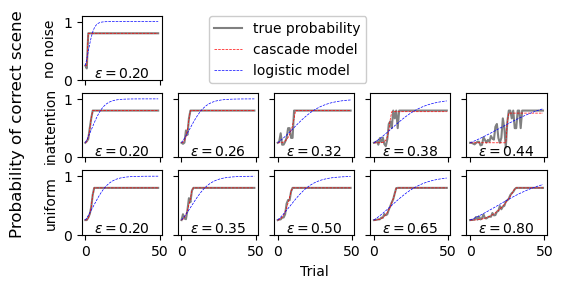

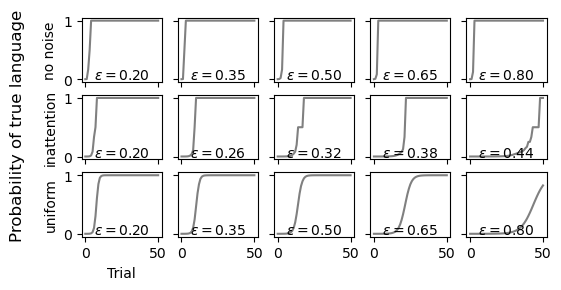

In [341]:
plot_bayesian_results(
    {
        'no noise': bayesian_results_noisefree,
        'inattention': bayesian_results_ignore,
        'uniform': bayesian_results_uniform,
    },
    noise_vectors=[noise_vector_ignore, noise_vector_uniform, noise_vector_ignore],
    # x_max=30,
    pmax_for_true=0.8,
    save=True,
    pathadd='ceiling=0.8'
)

Plot the shape of the curves marginalized across participants

In [362]:
n_participants = 20
noise_vector = np.linspace(0.2, 0.7, n_participants)

In [363]:

bayesian_results_ignore_marginalize = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=20)

Text(0.5, 1.0, '$\\epsilon=$0.35')

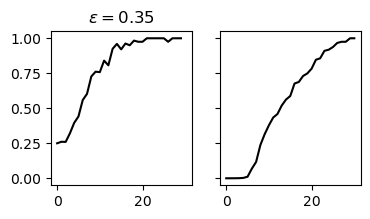

In [364]:
history_states = bayesian_results_ignore_marginalize['history_states']
true_interpretation_func, true_word_order = bayesian_results_ignore_marginalize['indices_true_language'].T
probs_true_langs_mean = history_states[
    :,
    np.arange(n_participants),
    true_interpretation_func, 
    true_word_order
].mean(axis=1)

hist_p_scenes = bayesian_results_ignore_marginalize['history_p_scenes']
p_correct_scene_mean = (
        hist_p_scenes[bayesian_results_ignore_marginalize['true_scenes'][:,:,None] 
        == bayesian_results_ignore_marginalize['indices_scenes_trials']]
        .reshape(n_trials,-1)
    ).mean(axis=1)

fig, (correct_ax, probs_ax) = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)

correct_ax.plot(p_correct_scene_mean, color='black')
probs_ax.plot(probs_true_langs_mean, color='black')

correct_ax.set_title(f'$\\epsilon=${noise:.2f}')

# Specific language

In [ ]:
index_true_language = (2,3)

scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

word_order_prior, interpret_prior = simulation_functions.define_priors(
    word_orders, 
    language_interpret
)

trials = simulation_functions.generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

history, _ = simulation_functions.run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=True
)

In [ ]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.006944444444444444,
 0.16666666666666666,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

# Run multiple experiments:

1. Considering negative evidence (i.e., not updating when they get it wrong)

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

In [ ]:
np.array(histories).shape

(100, 11, 5040, 6)

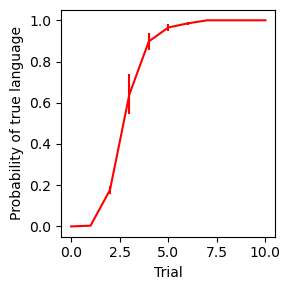

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot(
#     np.array(true_hists).T,
#     color='black',
#     alpha=0.05
# )
ax.errorbar(
    np.arange(len(means)), 
    means, 
    variances,
    color='red'
)
ax.set_xlabel('Trial')
ax.set_ylabel('Probability of true language')
plt.tight_layout()
fig.savefig('figures/perfectBayesian.png', dpi=300)

2. Without considering negative evidence

IntProgress(value=0)

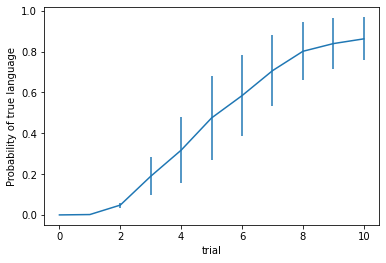

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()